## Import Library

In [1]:
import pandas as pd
import datetime as dt

import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

## Reload and Import or Clean the data

In [2]:
#  Let's quickly reload and clean or import our data ✌
df = pd.read_excel('../data/Online_Retail.xlsx', engine='openpyxl')
df_clean = df.dropna(subset=['CustomerID'])
df_final = df_clean[(df_clean['Quantity'] > 0) & (df_clean['UnitPrice'] > 0)].copy()
df_final['TotalSum'] = df_final['Quantity'] * df_final['UnitPrice']
df_final.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalSum
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [3]:
df_final.tail()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalSum
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France,10.20
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,12.60
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France,14.85


# Part 2 👉 RFM ANALYSIS

## Fixing the date type to calculate time distances

In [4]:
df_final['InvoiceDate'] = pd.to_datetime(df_final['InvoiceDate'])

# Establish a pinpoint evaluation date (1 day after the very last transaction in the history)
snapshot_date = df_final['InvoiceDate'].max() + dt.timedelta(days=1)
snapshot_date

Timestamp('2011-12-10 12:50:00')

## Grouping the row records by CustomerID to map Recency, Frequency, and Monetary metrics

In [5]:
rfm_table = df_final.groupby(['CustomerID']).agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days, # Recency
    'InvoiceNo': 'count',                                   # Frequency
    'TotalSum': 'sum'                                       # Monetary
})

# 5. Rename for analytical clarity
rfm_table.rename(columns={
    'InvoiceDate': 'Recency',
    'InvoiceNo': 'Frequency',
    'TotalSum': 'Monetary'
}, inplace=True)

print("✅ RFM Aggregation Engine Complete!")
rfm_table.head()

✅ RFM Aggregation Engine Complete!


,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,182,4310.00
12348.0,75,31,1797.24
12349.0,19,73,1757.55
12350.0,310,17,334.40


## Inspecting Customer Segments

In [6]:
# 📊 Calculate key statistical boundaries for the new customer groups
print("--- Customer Base Overview ---")
print(f"Total Unique Customers Tracked: {rfm_table.shape[0]}\n")

# Review standard averages across the entire user base
print(rfm_table.describe())

--- Customer Base Overview ---
Total Unique Customers Tracked: 4338

           Recency    Frequency       Monetary
count  4338.000000  4338.000000    4338.000000
mean     92.536422    91.720609    2054.266460
std     100.014169   228.785094    8989.230441
min       1.000000     1.000000       3.750000
25%      18.000000    17.000000     307.415000
50%      51.000000    41.000000     674.485000
75%     142.000000   100.000000    1661.740000
max     374.000000  7847.000000  280206.020000


<div style="background-color: #444C38; color: #FFFFFF; padding: 15px; border-radius: 5px; font-size: 16px;">
    <p>
Looking at the Monetary row, the average (mean) customer spent about 💲2,054 but at least one top customer (max) spent an incredible 💲280,206!
    </p>
    </p>
Also, looking at Frequency: the 75th percentile is 100 orders, but the maximum is a massive 7,847 orders. This proves that the data has major outlier —heavy "whales" that skew the averages.
    </p>
</div>

<div>
    <h2> Assigning Quartile Scores (1 to 4)</h2>
    <p>
        We will divide the customer scores into four equal buckets based on percentiles (25%, 50%, 75%) 
    </p>
        <p>
            For Recency, a lower number is better (ordered recently), so a small number gets a high score of 4.
            For Frequency and Monetary, a higher number is better, so large numbers get a high score of 4.
        </p>
</div>

In [7]:
# 📊 Create quartile scoring functions
# Recency: Lower is better (1 = inactive for a long time, 4 = active recently)
r_labels = range(4, 0, -1) 
# Frequency & Monetary: Higher is better (1 = low engagement/spend, 4 = high engagement/spend)
f_labels = range(1, 5)
m_labels = range(1, 5)

# Cut the data into quartiles using pandas qcut
r_groups = pd.qcut(rfm_table['Recency'], q=4, labels=r_labels)
f_groups = pd.qcut(rfm_table['Frequency'], q=4, labels=f_labels)
m_groups = pd.qcut(rfm_table['Monetary'], q=4, labels=m_labels)

# Assign these new score columns back to our main table
rfm_table = rfm_table.assign(R=r_groups.values, F=f_groups.values, M=m_groups.values)

# Create an overall concatenated string score (e.g., 444, 111) and a combined numeric score
rfm_table['RFM_Segment'] = rfm_table['R'].astype(str) + rfm_table['F'].astype(str) + rfm_table['M'].astype(str)
rfm_table['RFM_Score'] = rfm_table[['R', 'F', 'M']].sum(axis=1)

print("✅ RFM Scores Assigned Successfully!")
rfm_table.head()


✅ RFM Scores Assigned Successfully!


,Recency,Frequency,Monetary,R,F,M,RFM_Segment,RFM_Score
CustomerID,,,,,,,,
12346.0,326,1,77183.60,1,1,4,114,6
12347.0,2,182,4310.00,4,4,4,444,12
12348.0,75,31,1797.24,2,2,4,224,8
12349.0,19,73,1757.55,3,3,4,334,10
12350.0,310,17,334.40,1,1,2,112,4


## Defining Business Segments Based on the Scores

In [8]:
# 🎯 Function to bucket numeric RFM scores into business segments
def segment_me(df):
    if df['RFM_Score'] >= 10:
        return '🥇 Champions / VIPs'
    elif (df['RFM_Score'] >= 7) and (df['RFM_Score'] < 10):
        return '🥈 Loyal & Active Customers'
    elif (df['RFM_Score'] >= 4) and (df['RFM_Score'] < 7):
        return '⚠️ At-Risk / Churn Risk'
    else:
        return '🛑 Lost Customers'

# Apply the segment names to your table
rfm_table['General_Segment'] = rfm_table.apply(segment_me, axis=1)

# Check the size of each newly formed group
print(rfm_table['General_Segment'].value_counts())


General_Segment
⚠️ At-Risk / Churn Risk       1358
🥈 Loyal & Active Customers    1330
🥇 Champions / VIPs            1265
🛑 Lost Customers               385
Name: count, dtype: int64


## Plotting Customer Segments

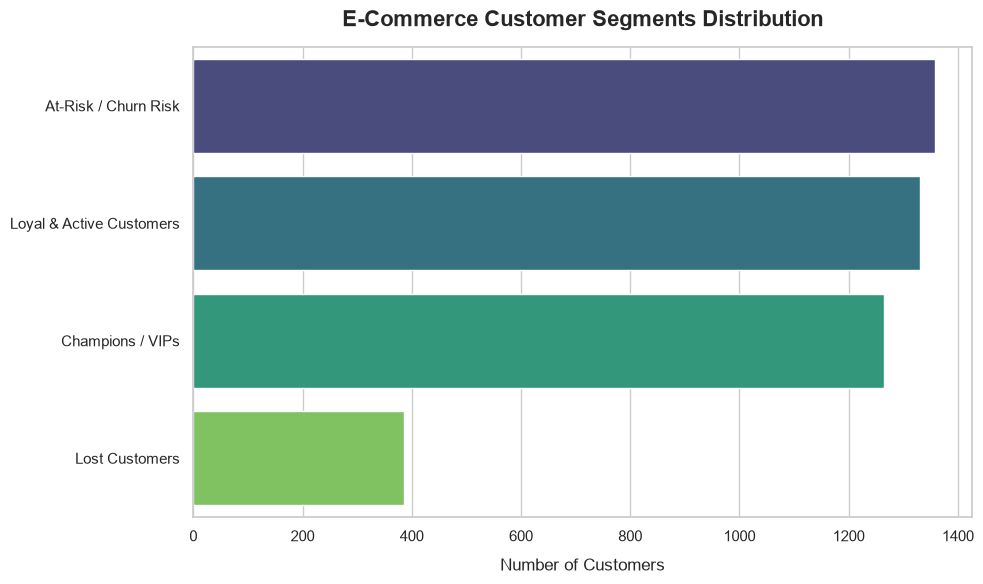

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean visual style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# Count the frequency of each customer segment
segment_counts = rfm_table['General_Segment'].value_counts()

# 🧹 Clean the names for the chart axis to remove emoji warning errors
clean_index = [name.split(' ', 1)[1] if ' ' in name else name for name in segment_counts.index]

# Create a horizontal bar chart with text-only names
sns.barplot(
    x=segment_counts.values, 
    y=clean_index, 
    palette="viridis",
    hue=clean_index,
    legend=False
)

# Design polish
plt.title('E-Commerce Customer Segments Distribution', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Number of Customers', fontsize=12, labelpad=10)
plt.ylabel('', fontsize=12)

# Save the clean plot directly into your images folder for GitHub
plt.tight_layout()
plt.savefig('../images/customer_segments_distribution.png', dpi=300)
plt.show()
